In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import mikeio

ds = xr.open_dataset(r"D:\Phd Research\Data\Wave Data\3bb79466b9b987f8332ce6a935379f7e_wave_1943_July.nc")
ds

<xarray.Dataset>
Dimensions:     (valid_time: 744, latitude: 6, longitude: 7)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 1943-07-01 ... 1943-07-31T23:00:00
  * latitude    (latitude) float64 28.62 28.12 27.62 27.12 26.62 26.12
  * longitude   (longitude) float64 -97.85 -97.35 -96.85 ... -95.35 -94.85
    expver      (valid_time) object ...
Data variables:
    mwd         (valid_time, latitude, longitude) float32 ...
    mwp         (valid_time, latitude, longitude) float32 ...
    swh         (valid_time, latitude, longitude) float32 ...
    pp1d        (valid_time, latitude, longitude) float32 ...
    wdw         (valid_time, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-09-18T01:11 GRIB to CDM+CF via cfgrib-0.9.1...

In [2]:
ds["swh"]

<xarray.DataArray 'swh' (valid_time: 744, latitude: 6, longitude: 7)>
array([[[     nan,      nan, ..., 0.74106 , 0.746156],
        [     nan,      nan, ..., 0.774591, 0.809488],
        ...,
        [     nan, 0.471109, ..., 0.573396, 0.591691],
        [     nan,      nan, ..., 0.535524, 0.549768]],

       [[     nan,      nan, ..., 0.701615, 0.700387],
        [     nan,      nan, ..., 0.753877, 0.782998],
        ...,
        [     nan, 0.46328 , ..., 0.570542, 0.58912 ],
        [     nan,      nan, ..., 0.532822, 0.546212]],

       ...,

       [[     nan,      nan, ..., 0.793664, 0.778428],
        [     nan,      nan, ..., 0.864129, 0.837136],
        ...,
        [     nan, 0.82248 , ..., 0.925233, 0.893159],
        [     nan,      nan, ..., 0.945954, 0.912713]],

       [[     nan,      nan, ..., 0.779   , 0.763939],
        [     nan,      nan, ..., 0.84771 , 0.821541],
        ...,
        [     nan, 0.801072, ..., 0.914269, 0.883698],
        [     nan,      nan, ..., 0.934815, 0.905182]]], dtype=float32)
Coordinates:
    number      int64 0
  * valid_time  (valid_time) datetime64[ns] 1943-07-01 ... 1943-07-31T23:00:00
  * latitude    (latitude) float64 28.62 28.12 27.62 27.12 26.62 26.12
  * longitude   (longitude) float64 -97.85 -97.35 -96.85 ... -95.35 -94.85
    expver      (valid_time) object '0001' '0001' '0001' ... '0001' '0001'
Attributes:
    GRIB_paramId:                             140229
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      42
    GRIB_typeOfLevel:                         meanSea
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    GRIB_uvRelativeToGrid:                    0
    GRIB_NV:                                  0
    GRIB_Nx:                                  7
    GRIB_Ny:                                  6
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           swh
    GRIB_gridDefinitionDescription:           Latitude/Longitude Grid
    GRIB_iDirectionIncrementInDegrees:        0.5
    GRIB_iScansNegatively:                    0
    GRIB_jDirectionIncrementInDegrees:        0.5
    GRIB_jPointsAreConsecutive:               0
    GRIB_jScansPositively:                    0
    GRIB_latitudeOfFirstGridPointInDegrees:   28.62
    GRIB_latitudeOfLastGridPointInDegrees:    26.12
    GRIB_longitudeOfFirstGridPointInDegrees:  -97.85
    GRIB_longitudeOfLastGridPointInDegrees:   -94.85
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Significant height of combined ...
    GRIB_shortName:                           swh
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Significant height of combined ...
    units:                                    m
    standard_name:                            unknown
    GRIB_meanSea:                             0.0

In [3]:
ds0 = ds.isel(valid_time=0)
ds0

<xarray.Dataset>
Dimensions:     (latitude: 6, longitude: 7)
Coordinates:
    number      int64 0
    valid_time  datetime64[ns] 1943-07-01
  * latitude    (latitude) float64 28.62 28.12 27.62 27.12 26.62 26.12
  * longitude   (longitude) float64 -97.85 -97.35 -96.85 ... -95.35 -94.85
    expver      object '0001'
Data variables:
    mwd         (latitude, longitude) float32 nan nan nan ... 130.8 116.3 103.6
    mwp         (latitude, longitude) float32 nan nan nan ... 4.685 4.637 4.612
    swh         (latitude, longitude) float32 nan nan nan ... 0.5355 0.5498
    pp1d        (latitude, longitude) float32 nan nan nan ... 4.543 4.451 4.348
    wdw         (latitude, longitude) float32 nan nan nan ... 0.8937 0.9281
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-09-18T01:11 GRIB to CDM+CF via cfgrib-0.9.1...

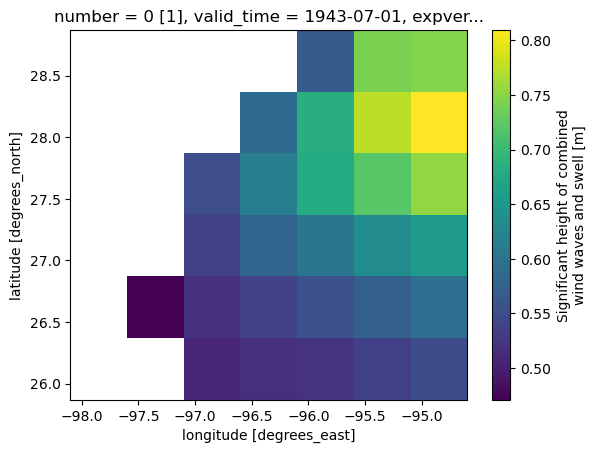

In [5]:
ds0.swh.plot()

In [6]:
ds_aoi = ds.sel(longitude=slice(-97.85,-94.61),
                latitude=slice(29,26.12)) # N -> S
ds_aoi

<xarray.Dataset>
Dimensions:     (valid_time: 744, latitude: 6, longitude: 7)
Coordinates:
    number      int64 0
  * valid_time  (valid_time) datetime64[ns] 1943-07-01 ... 1943-07-31T23:00:00
  * latitude    (latitude) float64 28.62 28.12 27.62 27.12 26.62 26.12
  * longitude   (longitude) float64 -97.85 -97.35 -96.85 ... -95.35 -94.85
    expver      (valid_time) object '0001' '0001' '0001' ... '0001' '0001'
Data variables:
    mwd         (valid_time, latitude, longitude) float32 nan nan ... 132.8
    mwp         (valid_time, latitude, longitude) float32 nan nan ... 5.026
    swh         (valid_time, latitude, longitude) float32 nan nan ... 0.9052
    pp1d        (valid_time, latitude, longitude) float32 nan nan ... 5.973
    wdw         (valid_time, latitude, longitude) float32 nan nan ... 0.5634
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-09-18T01:11 GRIB to CDM+CF via cfgrib-0.9.1...

In [7]:
time = pd.DatetimeIndex(ds.valid_time)
time

DatetimeIndex(['1943-07-01 00:00:00', '1943-07-01 01:00:00',
               '1943-07-01 02:00:00', '1943-07-01 03:00:00',
               '1943-07-01 04:00:00', '1943-07-01 05:00:00',
               '1943-07-01 06:00:00', '1943-07-01 07:00:00',
               '1943-07-01 08:00:00', '1943-07-01 09:00:00',
               ...
               '1943-07-31 14:00:00', '1943-07-31 15:00:00',
               '1943-07-31 16:00:00', '1943-07-31 17:00:00',
               '1943-07-31 18:00:00', '1943-07-31 19:00:00',
               '1943-07-31 20:00:00', '1943-07-31 21:00:00',
               '1943-07-31 22:00:00', '1943-07-31 23:00:00'],
              dtype='datetime64[ns]', length=744, freq=None)

In [8]:
g = mikeio.Grid2D(x=ds_aoi.longitude, y=ds_aoi.latitude[::-1], projection="LONG/LAT")
g

<mikeio.Grid2D>
x: [-97.85, -97.35, ..., -94.85] (nx=7, dx=0.5)
y: [26.12, 26.62, ..., 28.62] (ny=6, dy=0.5)
projection: LONG/LAT

In [9]:
das = [
    mikeio.DataArray(np.flip(ds_aoi.mwd.values, axis=1),
                     time=time, geometry=g,
                     item=mikeio.ItemInfo("mwd", mikeio.EUMType.Mean_Wave_Direction, mikeio.EUMUnit.degree)),

    mikeio.DataArray(np.flip(ds_aoi.mwp.values, axis=1),
                     time=time, geometry=g,
                     item=mikeio.ItemInfo("mwp", mikeio.EUMType.Wave_period, mikeio.EUMUnit.second)),

    mikeio.DataArray(np.flip(ds_aoi.pp1d.values, axis=1),
                     time=time, geometry=g,
                     item=mikeio.ItemInfo("pp1d", mikeio.EUMType.Wave_period, mikeio.EUMUnit.second)),

    mikeio.DataArray(np.flip(ds_aoi.swh.values, axis=1),
                     time=time, geometry=g,
                     item=mikeio.ItemInfo("swh", mikeio.EUMType.Wave_height, mikeio.EUMUnit.meter)),
    mikeio.DataArray(np.flip(ds_aoi.wdw.values, axis=1),
                     time=time, geometry=g,
                     item=mikeio.ItemInfo("wdw", mikeio.EUMType.Directional_Standard_Deviation, mikeio.EUMUnit.radian))
]

In [10]:
my_ds = mikeio.Dataset(das)
my_ds

<mikeio.Dataset>
dims: (time:744, y:6, x:7)
time: 1943-07-01 00:00:00 - 1943-07-31 23:00:00 (744 records)
geometry: Grid2D (ny=6, nx=7)
items:
  0:  mwd <Mean Wave Direction> (degree)
  1:  mwp <Wave period> (second)
  2:  pp1d <Wave period> (second)
  3:  swh <Wave height> (meter)
  4:  wdw <Directional Standard Deviation> (radian)

In [11]:
my_ds.to_dfs("D:\Phd Research\Data\Wave Data\Wavedata_1943_july.dfs2")